In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/cosowell_survey_v2.csv')

df.head()

,id,age,phase,gender,retired,education,education2,age_education,years_education,read_ability,...,reg3_num,reg5_num,reg7_num,reg8_num,reg10_num,expressive_suppression,reg2_num,reg4_num,reg6_num,reg9_num
0,954f38426899f477b39f0ceab6611c59,62,pre_cov,male,yes,"some college, no degree",college,21.0,15.0,excellent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,e42ca2d461291c17990883401d811f57,64,pre_cov,male,yes,associate's degree,college,24.0,18.0,excellent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,810c90536c9e0200fe8991b5276bb1f6,70,pre_cov,female,yes,master's degree,graduate,40.0,20.0,excellent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2d00d5f885b807e93814e8ee26aa1ba4,62,pre_cov,female,no,bachelor's degree,bachelor,21.0,16.0,very_good,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,642fd812a33d8e78b257c8b9a0d9f632,61,pre_cov,male,no,bachelor's degree,bachelor,22.0,16.0,excellent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Analysis by age group
We examined the three questions from the UCLA Loneliness Scale—feeling a lack of companionship, feeling left out, and feeling isolated—across different age groups. From the analysis, we observed that younger seniors, specifically those aged 55 to 64, are more likely to report experiencing these feelings frequently.

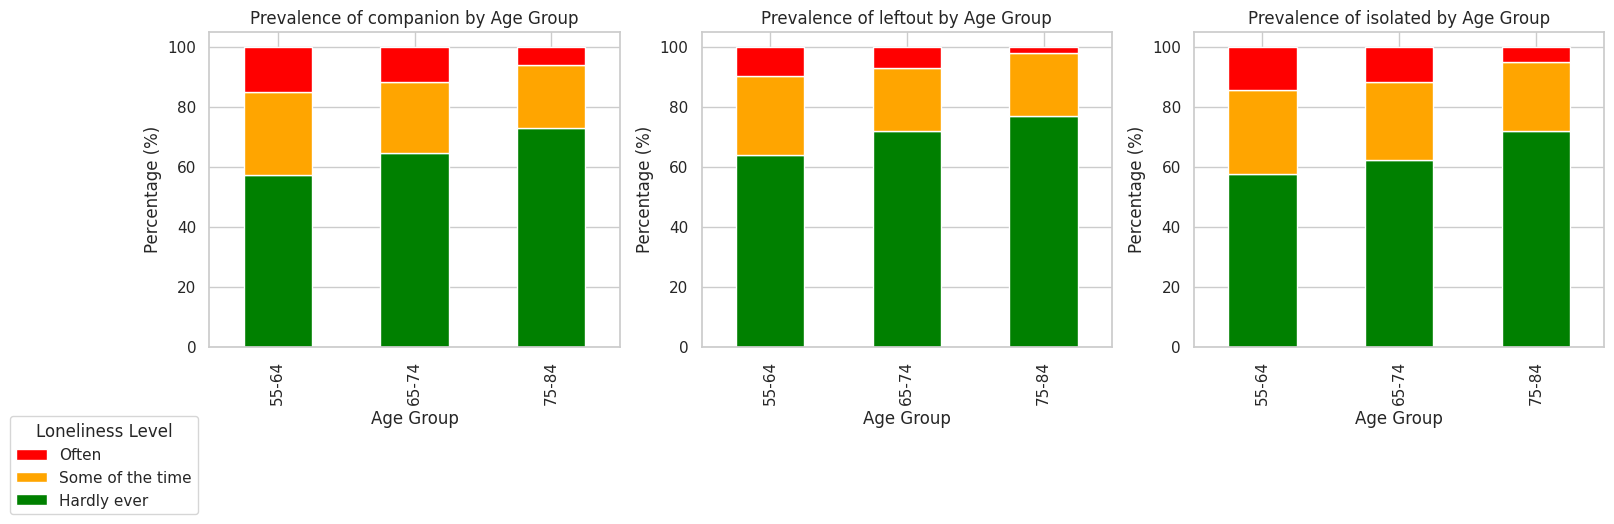

In [10]:
bins = [55 ,65, 75, 85, 100]
labels = ['55-64', '65-74', '75-84', '85+']
cols = ['companion','leftout','isolated']
df_filtered = df[~df[cols].isin(['NA']).any(axis=1)].copy()
df_filtered['age_group'] = pd.cut(df_filtered['age'], bins=bins, labels=labels, right=False)

cols = ['companion','leftout','isolated']
colours = ['green', 'orange', 'red']

# Map responses for readability
for col in cols:
    df_filtered[col+'_label'] = df_filtered[col].map({
        'hardly_ever':'Hardly ever',
        'some_of_the_time':'Some of the time',
        'often':'Often'
    })
prevalence = {}

order = ['Hardly ever', 'Some of the time', 'Often']

for col in cols:
    prevalence[col] = pd.crosstab(
        df_filtered['age_group'],
        df_filtered[col+'_label'],
        normalize='index')* 100

    prevalence[col] = prevalence[col][order]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols):
    prevalence[col].plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        legend=False,
        color=colours
    )
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_xlabel("Age Group")
    axes[i].set_title(f"Prevalence of {col} by Age Group")

handles, labels = axes[0].get_legend_handles_labels()

handles = handles[::-1]
labels = labels[::-1]

fig.legend(
    handles, labels,
    loc='lower left',
    bbox_to_anchor=(0.01, -0.1),
    title="Loneliness Level"
)

plt.subplots_adjust(bottom=0.25)
plt.show()

# Analysis by Living Arrangement
We found that individuals who live alone tend to report higher loneliness scores compared to those living with others.


/tmp/ipykernel_3034/1326780439.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


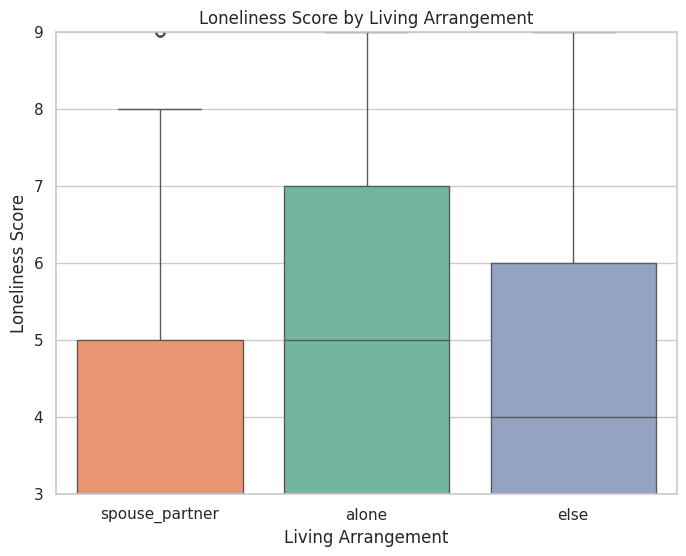

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df_filtered = df[~df["loneliness"].isin(['NA'])].copy()
df_filtered = df_filtered[~df_filtered["living_arrangements"].isin(['NA'])]

plt.figure(figsize=(8,6))

sns.boxplot(
    x='living_arrangements',
    y='loneliness',
    data=df_filtered,
    palette=['#fc8d62','#66c2a5','#8da0cb']
)

plt.title("Loneliness Score by Living Arrangement")
plt.xlabel("Living Arrangement")
plt.ylabel("Loneliness Score")
plt.ylim(3,9)

plt.show()

# Analysis by Behavioural Pattern

We analyzed the frequency of social meetings with friends and relatives, participation in group activities such as support groups or hobby groups, and engagement in volunteer work. Across all three variables, we observed a consistent trend: individuals with higher frequencies of social interaction and engagement tend to have lower loneliness scores. Among these, social meetings with friends and relatives appeared to have the strongest association with reduced loneliness.


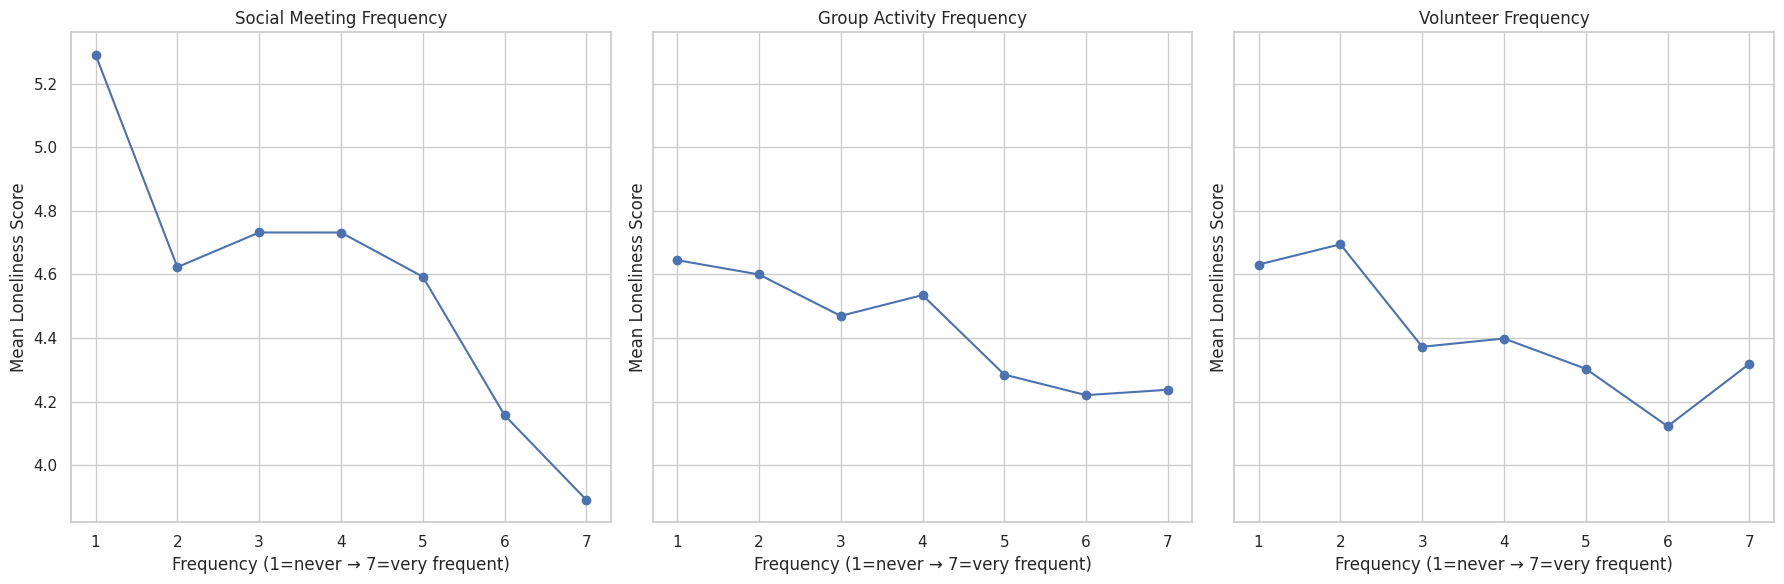

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

cols = ['social_meet_freq','professional_meet_freq','volunteer_meet_freq']

label_map = {
    'social_meet_freq': 'Social Meeting Frequency',
    'professional_meet_freq': 'Group Activity Frequency',
    'volunteer_meet_freq': 'Volunteer Frequency'
}

# frequency scale mapping
freq_map = {
    'never':1,
    'less_than_once_a_year':2,
    'about_once_or_twice_a_year':3,
    'several_times_a_year':4,
    'about_once_a_month':5,
    'every_week':6,
    'several_times_a_week':7
}

df_filtered = df.dropna(subset=['loneliness']).copy()

fig, axes = plt.subplots(1,3,figsize=(18,6),sharey=True)

for i, col in enumerate(cols):

    data = df_filtered.copy()

    # convert categories to numbers
    data[col] = data[col].map(freq_map)

    data = data.dropna(subset=[col])

    mean_loneliness = data.groupby(col)['loneliness'].mean()

    axes[i].plot(mean_loneliness.index, mean_loneliness.values, marker='o')

    axes[i].set_title(label_map[col])
    axes[i].set_xlabel("Frequency (1=never → 7=very frequent)")
    axes[i].set_ylabel("Mean Loneliness Score")
    axes[i].set_xticks(range(1,8))

plt.tight_layout()
plt.show()

#Cosowell-written life narratives

To analyse the linguistic pattern.We found that elderly individuals with higher loneliness scores tend to use more first-person pronouns in their narratives, reflecting greater self-focus. Also, they tend to use fewer first-person plural pronouns, such as “we” and “us,” which reflects less reference to friends or family members.


In [4]:
df_essay = pd.read_csv('/content/drive/MyDrive/cosowell_matched_v2.csv')

df_essay.head(20)

,id,doc_id,paragraph_id,sentence_id,sentence,token_id,token,lemma,upos,xpos,feats,head_token_id,dep_rel,deps,misc,worktimeinseconds,narrative,type,test_session
0,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,1,my,my,PRON,PRP$,Number=Sing|Person=1|Poss=Yes|PronType=Prs,2,nmod:poss,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
1,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,2,wife,wife,NOUN,NN,Number=Sing,4,nsubj,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
2,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,3,was,be,AUX,VBD,Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbF...,4,aux,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
3,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,4,finishing,finish,VERB,VBG,Tense=Pres|VerbForm=Part,0,root,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
4,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,5,up,up,ADP,RP,NaN,4,compound:prt,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
5,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,6,washing,wash,VERB,VBG,Tense=Pres|VerbForm=Part,4,ccomp,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
6,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,7,dishes,dish,NOUN,NNS,Number=Plur,6,obj,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
7,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,8,yesterday,yesterday,NOUN,NN,Number=Sing,9,compound,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
8,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,9,evening,evening,NOUN,NN,Number=Sing,6,obl:tmod,NaN,SpaceAfter=No,1776.0,My wife was finishing up washing dishes yester...,cookie,t1
9,d2f23157fcc095159a1996be02629752,783f26788a6c123c7287a423b93e6ad8,1,1,My wife was finishing up washing dishes yester...,10,.,.,PUNCT,.,NaN,4,punct,NaN,NaN,1776.0,My wife was finishing up washing dishes yester...,cookie,t1


In [5]:
df_merged = df_essay.merge(df[['id','loneliness']], on='id', how='left')

In [6]:
print(df_merged.head())

                                 id                            doc_id  \
0  d2f23157fcc095159a1996be02629752  783f26788a6c123c7287a423b93e6ad8   
1  d2f23157fcc095159a1996be02629752  783f26788a6c123c7287a423b93e6ad8   
2  d2f23157fcc095159a1996be02629752  783f26788a6c123c7287a423b93e6ad8   
3  d2f23157fcc095159a1996be02629752  783f26788a6c123c7287a423b93e6ad8   
4  d2f23157fcc095159a1996be02629752  783f26788a6c123c7287a423b93e6ad8   

   paragraph_id  sentence_id  \
0             1            1   
1             1            1   
2             1            1   
3             1            1   
4             1            1   

                                            sentence  token_id      token  \
0  My wife was finishing up washing dishes yester...         1         my   
1  My wife was finishing up washing dishes yester...         2       wife   
2  My wife was finishing up washing dishes yester...         3        was   
3  My wife was finishing up washing dishes yester...        

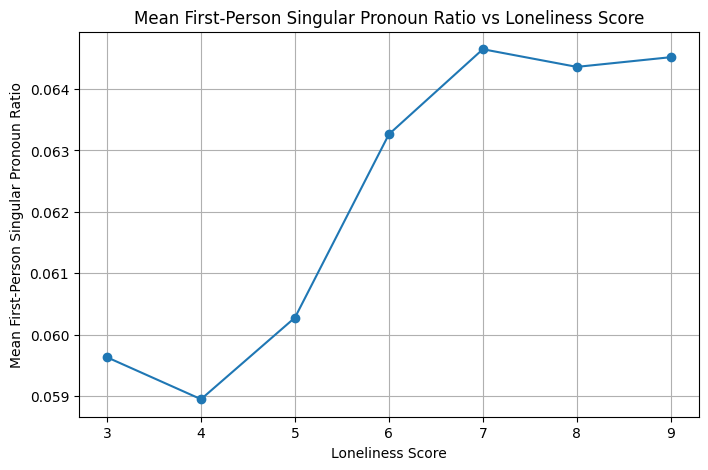

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df_unique = df_merged[['narrative', 'loneliness']].drop_duplicates()

# Count tokens and first-person pronouns
first_person_prons = ['i', 'me', 'my', 'mine', 'myself']

df_unique['n_tokens'] = df_unique['narrative'].apply(lambda x: len(x.split()))
df_unique['first_person_count'] = df_unique['narrative'].apply(
    lambda x: sum(token in first_person_prons for token in x.lower().split())
)

# Compute ratio
df_unique['first_person_ratio'] = df_unique['first_person_count'] / df_unique['n_tokens']

# Group by loneliness score and compute mean ratio
df_plot = df_unique.groupby('loneliness')['first_person_ratio'].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
plt.plot(df_plot['loneliness'], df_plot['first_person_ratio'], marker='o')
plt.title("Mean First-Person Singular Pronoun Ratio vs Loneliness Score")
plt.xlabel("Loneliness Score")
plt.ylabel("Mean First-Person Singular Pronoun Ratio")
plt.grid(True)
plt.show()

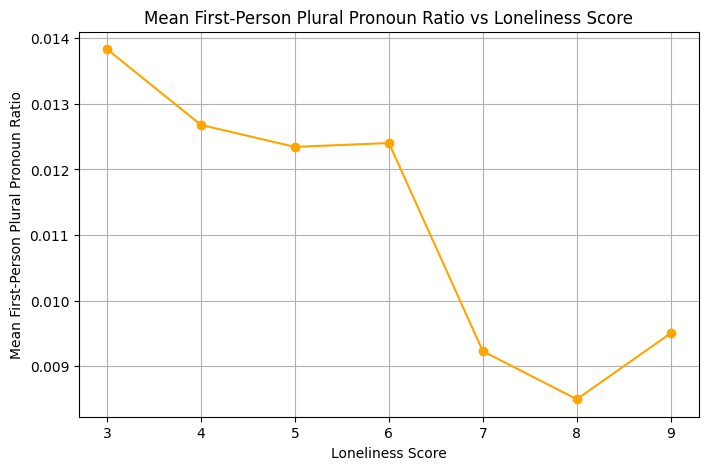

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_unique = df_merged[['narrative', 'loneliness']].drop_duplicates()

# Count tokens and first-person plural pronouns
first_person_plural_prons = ['we', 'us', 'our', 'ours', 'ourselves']

df_unique['n_tokens'] = df_unique['narrative'].apply(lambda x: len(x.split()))
df_unique['first_person_plural_count'] = df_unique['narrative'].apply(
    lambda x: sum(token in first_person_plural_prons for token in x.lower().split())
)

# Compute ratio
df_unique['first_person_plural_ratio'] = df_unique['first_person_plural_count'] / df_unique['n_tokens']

# Group by loneliness score and compute mean ratio
df_plot_plural = df_unique.groupby('loneliness')['first_person_plural_ratio'].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
plt.plot(df_plot_plural['loneliness'], df_plot_plural['first_person_plural_ratio'], marker='o', color='orange')
plt.title("Mean First-Person Plural Pronoun Ratio vs Loneliness Score")
plt.xlabel("Loneliness Score")
plt.ylabel("Mean First-Person Plural Pronoun Ratio")
plt.grid(True)
plt.show()